In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
from encoder_decoder import*
import matplotlib.pyplot as plt

# Check vocab and define encoding/decoding functions (from int to char and viceversa)
# Define the vocab and vocab_size

In [2]:
# first import the little dictionary frol it_es_cognates.txt

italian_words = []
spanish_words = []

with open("it_es_cognates.txt", encoding="utf-8") as f:
    for line in f:
        line = line.strip()
        if not line or line.startswith("#"):
            continue
        it, es = line.split(";") # words separated by ;
        italian_words.append(it.lower())
        spanish_words.append(es.lower())

# check the number of words in the list of cognates
print(len(italian_words), "pairs")
print(italian_words[:5], spanish_words[:5])

# find all characters appearing in the list of cognates
all_chars = set()
for word in spanish_words + italian_words:
    all_chars.update(word)
all_chars = sorted(all_chars)

# add the special caracters: pad, start of string, end of string, unknown
specials = ['<pad>', '<sos>', '<eos>', '<unk>']
vocab = specials + all_chars

# build the dictionaries, just use the enumeration of vocab to assign an integer to every character
char_to_idx = {ch: i for i, ch in enumerate(vocab)}
idx_to_char = {i: ch for ch, i in char_to_idx.items()}

# check the characters in the vocabulary, and its length
print("vocab: ", vocab)
print("vocab length:", len(vocab))

# test word size in the vocabulary (need to know the dimension of the words I am going to have in the model - by padding)
# I will add 2 or 3 just to be on the safe side for future additions to the dictionary, getting, say, to 20
print("Max length of spanish words: ", max(len(w) for w in spanish_words))
print("Max length of italian words: ", max(len(w) for w in italian_words))

def encode_source(word, max_len = 20):
    # input: no sos/eos needed
    ids = [char_to_idx.get(c, char_to_idx['<unk>']) for c in word][:max_len] # use the char to int dictionary
    ids += [char_to_idx['<pad>']] * (max_len - len(ids)) # fill with '<pad>' until the prescribed length max_len
    return torch.tensor(ids)

def encode_target(word, max_len = 20):
    # output: needs sos/eos since decoder generates it step by step, they will replace two <pad> 
    ids = [char_to_idx['<sos>']] + [char_to_idx.get(c, char_to_idx['<unk>']) for c in word][:max_len-2] + [char_to_idx['<eos>']]
    ids += [char_to_idx['<pad>']] * (max_len - len(ids))
    return torch.tensor(ids) 

def decode_source(ids):
    
    ids_numpy = ids.numpy()
    chars = []
    for i in ids_numpy:
        ch = idx_to_char[i] # use the integer to char dictionary
        if ch == '<pad>':
            break  # padding marks the end of real content
        chars.append(ch)
    return ''.join(chars)

# test
print(encode_source('castoro'))
print(decode_source(encode_source('castoro'))) 
print(decode_source(encode_source('è'))) # check unknown characters


# now test the embedding
vocab_size = len(char_to_idx)
d_model = 32 # needs to be large enough but does not have to be larger than number of characters - in fact for LLMs it is smaller than the number of tokens
embed = nn.Embedding(vocab_size, d_model, padding_idx=char_to_idx['<pad>'])

print(embed(encode_source('castoro')))

1396 pairs
['a', 'acqua', 'acque', 'aeroporti', 'aeroporto'] ['a', 'agua', 'aguas', 'aeropuertos', 'aeropuerto']
vocab:  ['<pad>', '<sos>', '<eos>', '<unk>', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h', 'i', 'j', 'l', 'm', 'n', 'o', 'p', 'q', 'r', 's', 't', 'u', 'v', 'x', 'y', 'z', 'à', 'á', 'é', 'í', 'ñ', 'ó', 'ù', 'ú']
vocab length: 36
Max length of spanish words:  15
Max length of italian words:  13
tensor([ 6,  4, 21, 22, 17, 20, 17,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
         0,  0])
castoro
<unk>
tensor([[ 0.6360,  0.5293,  1.5236, -1.0112, -0.4003, -0.7857,  0.3259,  0.8177,
         -0.2147,  0.6650,  0.3580, -0.4714,  1.5135,  0.9526,  0.7073,  0.7016,
          0.2543,  0.5039, -0.1014, -0.0309,  0.9343,  0.4731, -0.9904, -0.3148,
         -1.0681, -1.3118, -0.7584, -0.8154, -0.7444, -0.9664, -1.4896,  0.2081],
        [-0.3214, -0.8523,  1.1878, -1.4592, -0.1818,  0.3665,  2.3052,  0.7806,
          1.2035,  2.2494, -1.6085, -0.2404, -1.0699, -0.2916, -0.6351,  2.0939,
 

# Various tests done while coding the class

In [3]:
# test if Encoder runs correctly

enco = Encoder(2, d_model = d_model, d_hidden = 4*d_model, dk = 8, dv = 8, h = 4)
pos_enco = PositionalEncodingModule(d_model=d_model)

encoded_word = pos_enco(enco(embed(encode_source('castoro')).unsqueeze(0)))
# print(encoded_word)

# ok

# test if Transformer runs correctly 

trafo = Transformer(n_layers = 3, d_model = d_model, vocab_size = vocab_size, char_to_idx = char_to_idx, dk = 8, dv = 8)

print(trafo(encode_source("castoro").unsqueeze(0), encode_source("diga").unsqueeze(0)))
print(trafo.generate_sequence(encode_source("castoro").unsqueeze(0)))

tensor([[[ 5.6231e-01,  9.4508e-01,  3.5994e-01, -7.9498e-01, -1.0243e+00,
           7.5945e-01,  8.0413e-01,  5.8518e-02, -4.1259e-01,  4.6967e-01,
           2.1283e-01, -4.6751e-01,  3.1720e-01,  4.9074e-01, -8.9582e-01,
           8.9132e-02,  4.2847e-01, -3.3307e-01, -7.9866e-01,  3.0033e-01,
           2.2307e-01, -2.0427e-01,  1.9188e-01,  4.7635e-01, -2.1902e-01,
           6.1506e-01,  4.5330e-01,  9.4554e-02,  1.9072e-01,  4.8560e-01,
           1.0857e+00, -2.8319e-02, -4.4860e-03,  2.7488e-01, -9.2107e-01,
          -1.6381e-02],
         [ 1.2331e+00,  4.2314e-01,  6.3940e-01, -6.9443e-01, -1.2519e+00,
           5.7398e-01,  9.7084e-01,  5.2922e-01,  9.9509e-02, -8.2290e-02,
           1.4070e-01, -4.9680e-01,  2.6267e-01, -1.0702e-01,  1.6733e-01,
          -2.5820e-01, -3.3853e-01, -1.1250e+00, -8.7347e-01, -2.8162e-01,
           1.2185e+00, -6.6395e-01, -4.6261e-01,  3.9563e-01, -2.8432e-01,
           5.1678e-02,  4.5624e-01, -3.5501e-01,  2.4943e-01,  7.9412e-01,
 

In [4]:
def count_parameters_by_module(model: nn.Module, trainable_only: bool = True) -> dict:
    """counts the number of parameters, in total and for every submodule"""
    counts = {}
    for name, module in model.named_children():
        if trainable_only:
            n = sum(p.numel() for p in module.parameters() if p.requires_grad)
        else:
            n = sum(p.numel() for p in module.parameters())
        counts[name] = n
    counts["TOTAL"] = sum(counts.values())
    return counts

count_parameters_by_module(trafo)

{'embed': 1152,
 'pos_encoding': 0,
 'encoder': 38112,
 'decoder': 50976,
 'exit_linear_projection': 1188,
 'criterion': 0,
 'TOTAL': 91428}

# Fit the model

In [5]:

# define and train two models, a lighter and a heabier one
trafo1 = Transformer(n_layers = 1, d_model = 16, n_heads = 1, vocab_size = vocab_size, char_to_idx = char_to_idx, dk = 2, dv = 2, feedforward_hidden_dim_to_d_model_ratio = 2, lr = 0.01, scheduler_step_size=200)
trafo2 = Transformer(n_layers = 4, d_model = 32, n_heads = 8, vocab_size = vocab_size, char_to_idx = char_to_idx, dk = 8, dv = 8, feedforward_hidden_dim_to_d_model_ratio = 2, lr = 0.01, scheduler_step_size=200)

# here weight_decya = 1e-2
trafo1_weight_decay = Transformer(n_layers = 1, d_model = 16, n_heads = 1, vocab_size = vocab_size, char_to_idx = char_to_idx, dk = 2, dv = 2, feedforward_hidden_dim_to_d_model_ratio = 2, lr = 0.01, scheduler_step_size=200, use_weight_decay = True)
trafo2_weight_decay = Transformer(n_layers = 4, d_model = 32, n_heads = 8, vocab_size = vocab_size, char_to_idx = char_to_idx, dk = 8, dv = 8, feedforward_hidden_dim_to_d_model_ratio = 2, lr = 0.01, scheduler_step_size=200, use_weight_decay = True)


print('trafo1')
print(trafo1.count_parameters_by_module())
print('trafo2')
print(trafo2.count_parameters_by_module())

# lr = 0.01 seems to work as starting learning rate
print('train trafo1')
trafo1.fit_from_txt("it_es_cognates.txt", n_epochs=500)
print('train trafo2')
trafo2.fit_from_txt("it_es_cognates.txt", n_epochs=500)
print('train trafo1_wd')
trafo1_weight_decay.fit_from_txt("it_es_cognates.txt", n_epochs=500)
print('train trafo2_wd')
trafo2_weight_decay.fit_from_txt("it_es_cognates.txt", n_epochs=500)

trafo1
{'embed': 576, 'pos_encoding': 0, 'encoder': 1286, 'decoder': 1468, 'exit_linear_projection': 612, 'criterion': 0, 'TOTAL': 3942}
trafo2
{'embed': 1152, 'pos_encoding': 0, 'encoder': 50944, 'decoder': 84864, 'exit_linear_projection': 1188, 'criterion': 0, 'TOTAL': 138148}
train trafo1
Epoch  0 / 500  loss =  3.8119893074035645  loss_eval =  3.7990949153900146
Epoch  100 / 500  loss =  1.631994366645813  loss_eval =  1.6902453899383545
Epoch  200 / 500  loss =  1.2885727882385254  loss_eval =  1.4241890907287598
Epoch  300 / 500  loss =  1.177432656288147  loss_eval =  1.3538317680358887
Epoch  400 / 500  loss =  1.101582646369934  loss_eval =  1.3156418800354004
train trafo2
Epoch  0 / 500  loss =  3.7710533142089844  loss_eval =  3.7855167388916016
Epoch  100 / 500  loss =  0.6265853643417358  loss_eval =  1.370498538017273
Epoch  200 / 500  loss =  0.002645004540681839  loss_eval =  1.1591317653656006
Epoch  300 / 500  loss =  0.0018119198502972722  loss_eval =  1.209853887557

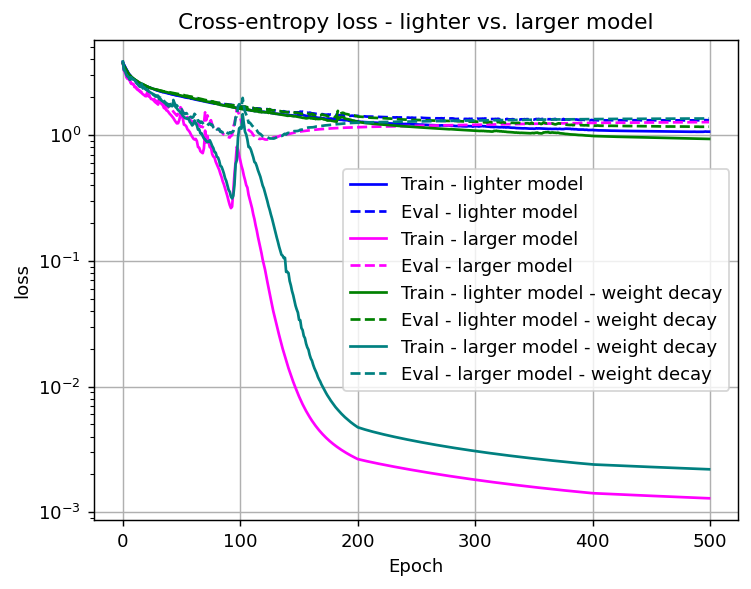

In [6]:
plt.figure(dpi = 130)
plt.title('Cross-entropy loss - lighter vs. larger model')
plt.xlabel('Epoch')
plt.ylabel('loss')
plt.grid()
plt.semilogy(trafo1.epochs, trafo1.losses, color = 'blue', label = 'Train - lighter model')
plt.semilogy(trafo1.epochs, trafo1.losses_eval, '--', color = 'blue', label = 'Eval - lighter model')
plt.semilogy(trafo2.epochs, trafo2.losses, color = 'magenta', label = 'Train - larger model')
plt.semilogy(trafo2.epochs, trafo2.losses_eval, '--', color = 'magenta', label = 'Eval - larger model')
plt.semilogy(trafo1_weight_decay.epochs, trafo1_weight_decay.losses, color = 'green', label = 'Train - lighter model - weight decay')
plt.semilogy(trafo1_weight_decay.epochs, trafo1_weight_decay.losses_eval, '--', color = 'green', label = 'Eval - lighter model - weight decay')
plt.semilogy(trafo2_weight_decay.epochs, trafo2_weight_decay.losses, color = 'teal', label = 'Train - larger model - weight decay')
plt.semilogy(trafo2_weight_decay.epochs, trafo2_weight_decay.losses_eval, '--', color = 'teal', label = 'Eval - larger model - weight decay')
plt.legend()
plt.show()

def translate_string(word, model):
    encoded_input = encode_source(word).unsqueeze(0)
    generated_sequence = model.generate_sequence(encoded_input).cpu().squeeze()[1:-1] # exclude sos at beginning and eos at end

    return decode_source(generated_sequence)

In [7]:
italian_words = ["gatto", "nave", "croci", "croce", "dito", "stretta", "stretti", "stretto", "strette", "pensate", "lasagna", "passato"]
expected_spanish_cognates_1 = [translate_string(word, trafo1) for word in italian_words]
expected_spanish_cognates_2 = [translate_string(word, trafo2) for word in italian_words]

print("Words in training dataset")
print(f"{'Italian':<15} | {'output light model':<20} | {'output larger model':<20}")
print("-" * 59)

for k in range(len(italian_words)):
    print(f"{italian_words[k]:<15} | {expected_spanish_cognates_1[k]:<20} | {expected_spanish_cognates_2[k]:<20}")

italian_words = ["lutti", "parato", "parata", "parati", "parate", "ottone", "castoro", "matti", "passata", "passate", "ossa"]
expected_spanish_cognates_1 = [translate_string(word, trafo1) for word in italian_words]
expected_spanish_cognates_2 = [translate_string(word, trafo2) for word in italian_words]

print("Words not in training dataset")
print(f"{'Italian':<15} | {'output light model':<20} | {'output larger model':<20}")
print("-" * 59)

for k in range(len(italian_words)):
    print(f"{italian_words[k]:<15} | {expected_spanish_cognates_1[k]:<20} | {expected_spanish_cognates_2[k]:<20}")

Words in training dataset
Italian         | output light model   | output larger model 
-----------------------------------------------------------
gatto           | tatado               | gato                
nave            | ntal                 | nacas               
croci           | cobrenos             | cruces              
croce           | cobes                | cruz                
dito            | dedo                 | dedo                
stretta         | sertado              | estrecha            
stretti         | sertos               | estrechos           
stretto         | soborto              | estrecho            
strette         | sostado              | estrechas           
pensate         | penadalas            | pensadas            
lasagna         | lasaña               | laspa               
passato         | pastadas             | pasado              
Words not in training dataset
Italian         | output light model   | output larger model 
----------------

In [8]:

# intermediate size
trafo3 = Transformer(n_layers = 2, d_model = 16, n_heads = 2, vocab_size = vocab_size, char_to_idx = char_to_idx, dk = 4, dv = 4, feedforward_hidden_dim_to_d_model_ratio = 2, lr = 0.01, scheduler_step_size=200)

print('trafo3')
print(trafo3.count_parameters_by_module())

# lr = 0.01 seems to work as starting learning rate
print('train trafo3')
trafo3.fit_from_txt("it_es_cognates.txt", n_epochs=500)


trafo3
{'embed': 576, 'pos_encoding': 0, 'encoder': 3376, 'decoder': 4544, 'exit_linear_projection': 612, 'criterion': 0, 'TOTAL': 9108}
train trafo3
Epoch  0 / 500  loss =  3.7063066959381104  loss_eval =  3.7152233123779297
Epoch  100 / 500  loss =  1.1422547101974487  loss_eval =  1.3832647800445557
Epoch  200 / 500  loss =  0.7061389684677124  loss_eval =  1.2600253820419312
Epoch  300 / 500  loss =  0.273805171251297  loss_eval =  1.13431978225708
Epoch  400 / 500  loss =  0.18215183913707733  loss_eval =  1.2072954177856445


# basically, overfitting
works fine on training dataset but not very well on random words. especially with large model. in some cases the lmodels give ok results for words not in training dataset (such as lutti - luchos). Note that the Spanish must does not have to exist in reality! It is only a hypothetical words obtained by applying the phonetical correspoendence between the two languages

same phenomenon if I change the number of layers n_layers. using weight decay with lambda = 1e-2 does not seem to make much of a difference

need bigger dataset

**regularization: try dropout and change weight decay parameter**